In [1]:
import folium
from folium.plugins import HeatMap
from folium import Icon
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt
import datetime as dt
import numpy as np
import os
import difflib
from scipy.interpolate import griddata
from google.cloud import bigquery
import ast
from cartopy.io import shapereader
from scipy.stats import pearsonr, spearmanr
import rasterio
from rasterio.transform import from_bounds


## OBS LOAD

In [2]:
def query_mistral_obs(var, start_date, end_date):
    """
    get the timeseries of the observations for the list of stations and dates
    dates should be provided in the format 'YYYY-MM-DDTHH:MM:SS' in UTC
    REF TIME is localized in UTC
    """

    project_name = 'a2a-dataplatformgt-pmt-prd'
    client = bigquery.Client(project=project_name)

    # dates to be queried
    dates = pd.date_range(start=start_date, end=end_date, freq='h').strftime('%Y-%m-%dT%H:%M:%S').tolist()

    # get the list of stations 
    list_station_name=[
    'Milano Lambrate', 'Milano v.Brera']
    
    # query the observations in UTC
    query= """ SELECT OBS.REF_TIME, OBS.LATITUDE, OBS.LONGITUDE, OBS.ALTITUDE, OBS.STATION_NAME, OBS.VALUE
        FROM `a2a-dataplatformgt-dwh-prd.L2.F_OBSERVATION_DATA_MISTRAL` OBS
        WHERE OBS.STATION_NAME IN UNNEST(@list_station_name_)
            AND OBS.PRODUCT= @var_
            AND OBS.REF_TIME IN UNNEST(ARRAY(SELECT PARSE_DATETIME("%Y-%m-%dT%H:%M:%S", d) FROM UNNEST(@dates_) AS d))
        ORDER BY OBS.REF_TIME; """
    
    job_config = bigquery.QueryJobConfig(
        query_parameters=[
            bigquery.ArrayQueryParameter("list_station_name_", "STRING", list_station_name),
            bigquery.ArrayQueryParameter("dates_", "STRING", dates),
            bigquery.ScalarQueryParameter("var_", "STRING", var),
            ]
        )
    
    result = client.query(query, job_config=job_config)
    dataset = result.to_dataframe(create_bqstorage_client=False).astype({'LATITUDE':float, 'LONGITUDE':float, 'VALUE':float})

    # convert the dates in datetime format and timezone aware
    dataset['REF_TIME'] = dataset['REF_TIME'].astype('datetime64[ns]').dt.tz_localize('UTC')

    return dataset

In [3]:
for i,year in enumerate(range(2020, 2024)):
    start_date = f'{year}-05-01T00:00:00'
    end_date = f'{year}-08-31T00:00:00'
    obs_df = query_mistral_obs('TEMPERATURE/DRY-BULB TEMPERATURE', start_date, end_date)
    obs_df['VALUE'] = obs_df['VALUE'] - 273.15 # convert to Celsius
    obs_df = obs_df[obs_df['VALUE'] > 0]
    obs_df_all = pd.DataFrame()
    if obs_df.empty:
        print(f"No data for {start_date} to {end_date}")
        continue
    if i == 0:
        obs_df_all = obs_df.copy()
    else:
        obs_df_all = pd.concat([obs_df_all, obs_df], ignore_index=True)

No data for 2020-05-01T00:00:00 to 2020-08-31T00:00:00
No data for 2021-05-01T00:00:00 to 2021-08-31T00:00:00
No data for 2022-05-01T00:00:00 to 2022-08-31T00:00:00


## TEMP OBS

In [4]:
def temp_obs(list_dates):
    """
    get the timeseries of the observations for the list of stations and dates

    dates should be provided in the format 'YYYY-MM-DDTHH:MM:SS' in UTC
    """

    
    # ------------ LOAD THE METADATA FROM FOMD ------------

    codice_stazione = {
        "MILANO Centro": 1,
        "MILANO Bicocca": 2,
        "MILANO Bovisa": 4,
        "MILANO Città Studi": 6,
        "MILANO Bocconi": 7,
        "MILANO Sud": 8,
        "MILANO Forze Armate": 9,
        "MILANO San Siro": 10
        }

    # add the observation data from FOMD
    filename=r"data_fomd\Dati2021-2024\Dati2021-2024\Metadata.xlsx"
    fomd=pd.read_excel(filename, sheet_name='METADATA', skipfooter=7)

    # rename the columns
    fomd.rename(columns={'Nome stazione':'STATION_NAME', 
                         'Latitudine  (gradi decimali WGS84)':'STATION_LAT', 
                         'Longitudine  (gradi decimali WGS84)':'STATION_LON', 
                         'Altezza Piano strada (m slm) *':'STATION_ALTITUDE_STRADA',
                         'Altezza Totale (m) **':'STATION_ALTITUDE'},
                         inplace=True)
    
    # set types
    fomd['STATION_LAT']=fomd['STATION_LAT'].astype(float)
    fomd['STATION_LON']=fomd['STATION_LON'].astype(float)
    fomd['STATION_ALTITUDE_STRADA']=fomd['STATION_ALTITUDE_STRADA'].astype(float)
    fomd['STATION_ALTITUDE']=fomd['STATION_ALTITUDE'].astype(float)
    
    # remove stars from the station names and uppercase Milano Forze Armate
    fomd['STATION_NAME']=fomd['STATION_NAME'].str.replace('*','')
    fomd['STATION_NAME']=fomd['STATION_NAME'].str.replace('Milano Forze Armate','MILANO Forze Armate')
    fomd['STATION_NAME']=fomd['STATION_NAME'].str.replace('MILANO San Siro ','MILANO San Siro')
    fomd['STATION_NAME']=fomd['STATION_NAME'].str.replace('MILANO Sud ','MILANO Sud')

    # add column SOURCE
    fomd['STATION_SOURCE']='FOMD'

    #  --------------- LOAD DATA -------------------

    path=r"data_fomd\Dati2021-2024\Dati2021-2024"
   
    # convert dates to datetime
    dates = list_dates

    list_files=[f for f in os.listdir(path) if 'Milano' in f]
    list_names = fomd[fomd['STATION_SOURCE']=='FOMD']['STATION_NAME'].to_list()

    for i, name in enumerate(list_names):
        # find closest string name in list_files
        f = difflib.get_close_matches('Milano_'+'_'.join(name.split(' ')[1:])+'.xlsx', list_files)[0]

        # variable name
        varname = str(codice_stazione[name])+'_'+'Tmed_V'
        sheetname = ' '.join(name.split(' ')[1:]) 
   
        filename=os.path.join(path, f)
        first_line=pd.read_excel(filename, header=None, nrows=1).values.flatten()  

        # find where approximately are the dates in the saved files
        if f!='Milano_Forze_Armate.xlsx':
            first_date_in_files=pd.to_datetime('2021-01-01T00:00:00').tz_localize('UTC')
        else:
            first_date_in_files=pd.to_datetime('2022-04-01T01:00:00').tz_localize('UTC')
        first_line_in_files=int((dates[0]-first_date_in_files).total_seconds()/3600 +1)
        last_line_in_files=int((dates[len(dates)-1]-first_date_in_files).total_seconds()/3600 +1)

        data=pd.read_excel(filename, sheet_name=sheetname, skiprows=first_line_in_files, nrows=last_line_in_files-first_line_in_files, names=first_line, usecols=['timestamp', varname])

        # timestamp as datetime, localize, convert to UTC and keep only the dates in the list
        data['timestamp']=pd.to_datetime(data['timestamp'])
        data['timestamp'] = data['timestamp']-pd.Timedelta(hours=1) # convert to UTC, but by hand as the data are in CET and not CEST
        data['timestamp'] = data['timestamp'].dt.tz_localize('UTC')
        data=data[data['timestamp'].isin(dates)]     

        # add the station name, lat and lon, and id_consuntivo
        data['STATION_LAT']=fomd[fomd['STATION_NAME']==name].iloc[0]['STATION_LAT']
        data['STATION_LON']=fomd[fomd['STATION_NAME']==name].iloc[0]['STATION_LON']
        data['STATION_ALTITUDE']=fomd[fomd['STATION_NAME']==name].iloc[0]['STATION_ALTITUDE']
        data['ID_CONSUNTIVO']=600000+codice_stazione[name]
        data['STATION_NAME']=name

        # rename columns
        data=data.rename(columns={'timestamp':'REF_TIME', varname:'VALUE'})

        # append to the dataset
        if i==0:
            data_all_stations=data
        else:
            data_all_stations=pd.concat([data_all_stations, data], ignore_index=True)

        # replace all 'nd' with np.nan
        data_all_stations['VALUE']=data_all_stations['VALUE'].replace('nd', np.nan)
        data_all_stations['VALUE']=data_all_stations['VALUE'].astype(float)        


    return fomd, data_all_stations

In [5]:
for i,year in enumerate(range(2020, 2024)):
    start_date = f'{year}-05-01'
    end_date = f'{year}-08-31'
    dates = pd.date_range(start=start_date, end=end_date, freq='h')
    dates = pd.Series([pd.to_datetime(d) for d in dates]).dt.tz_localize('UTC')
    if i == 0:
        all_dates = dates
    else:
        all_dates = pd.concat([all_dates, dates], ignore_index=True)

fomd, fomd_data =temp_obs(all_dates)

C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_5384\671197550.py:103: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_all_stations['VALUE']=data_all_stations['VALUE'].replace('nd', np.nan)
C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_5384\671197550.py:103: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_all_stations['VALUE']=data_all_stations['VALUE'].replace('nd', np.nan)


In [6]:
# append the two datasets
fomd_data.rename(columns={'STATION_LAT': 'LATITUDE', 'STATION_LON': 'LONGITUDE', 'STATION_ALTITUDE':'ALTITUDE'}, inplace=True)
# replace negative values with np.nan

obs_data = pd.concat([obs_df, fomd_data], ignore_index=True)
print(np.min(obs_data['REF_TIME']))
print(np.max(obs_data['REF_TIME']))

display(obs_data)

2021-05-01 00:00:00+00:00
2023-08-31 00:00:00+00:00


,REF_TIME,LATITUDE,LONGITUDE,ALTITUDE,STATION_NAME,VALUE,ID_CONSUNTIVO
0,2023-05-01 00:00:00+00:00,45.471660,9.189110,0E-38,Milano v.Brera,17.2,NaN
1,2023-05-01 00:00:00+00:00,45.496780,9.257520,120.00000000000000000000000000000000000000,Milano Lambrate,15.5,NaN
2,2023-05-02 01:00:00+00:00,45.496780,9.257520,120.00000000000000000000000000000000000000,Milano Lambrate,12.4,NaN
3,2023-05-02 01:00:00+00:00,45.471660,9.189110,0E-38,Milano v.Brera,12.7,NaN
4,2023-05-02 02:00:00+00:00,45.471660,9.189110,0E-38,Milano v.Brera,12.7,NaN
...,...,...,...,...,...,...,...
72665,2023-08-30 20:00:00+00:00,45.431289,9.200497,128.0,MILANO Sud,22.5,600008.0
72666,2023-08-30 21:00:00+00:00,45.431289,9.200497,128.0,MILANO Sud,21.6,600008.0
72667,2023-08-30 22:00:00+00:00,45.431289,9.200497,128.0,MILANO Sud,20.9,600008.0
72668,2023-08-30 23:00:00+00:00,45.431289,9.200497,128.0,MILANO Sud,20.4,600008.0


In [7]:
# Save obs_data to a CSV file
output_csv_path = "obs_data.csv"
obs_data.to_csv(output_csv_path, index=False)
print(f"obs_data saved to {output_csv_path}")

obs_data saved to obs_data.csv


## GUASTI LOAD

In [8]:
def get_guasti(fname, dstart, dend):

    # Load the dataset
    colnames = ['Data di guasto','OdL padre','Scatto','Rete','Impianto','Cavo',
                'Tratto cavo / da cabina elemento di rete presunto sede di guasto',
                'Tipo','da cabina','a cabina','Numero Nodo GIS - Solo rete 23 Kv giunti 12/20',
                'Priorità','Criticità','Fase lavorativa','Ricerca guasto','Impresa scavo','Riparazione',
                'Indirizzo dell\'intervento','Causa accertata','Intervento eseguito','Data rientro',
                'Note esercizio','Note fasi lavorative','Mese guasto','Mese riparazione','Anno',
                'Raggruppamento causa accertata','Origine','Agregazione impianto','verifica data']
    dataset = pd.read_excel(fname, sheet_name='Monitoraggio', header=None, names=colnames)

    # Convert the 'Data di guasto' column to datetime
    dataset['Data di guasto'] = pd.to_datetime(dataset['Data di guasto'], format='%d/%m/%Y', errors='coerce')
    dataset['Mese guasto'] = pd.to_datetime(dataset['Mese guasto'], format='%B', errors='coerce').dt.month
    dataset['Data rientro'] = pd.to_datetime(dataset['Data rientro'], format='%d/%m/%Y', errors='coerce')

    # localize to Europe/Rome
    dataset['Data di guasto'] = dataset['Data di guasto'].dt.tz_localize('Europe/Rome')
    dataset['Data rientro'] = dataset['Data rientro'].dt.tz_localize('Europe/Rome')

    # filter 
    dataset = dataset[(dataset['Data di guasto'].dt.date >=dstart) & (dataset['Data di guasto'].dt.date <= dend)]

    # 'da cabina' and 'a cabina' as string, remove spaces around
    dataset['da cabina'] = dataset['da cabina'].astype(str).str.strip()
    dataset['a cabina'] = dataset['a cabina'].astype(str).str.strip()

    # fill missing values in 'Causa accertata' with 'NON ACCERTATA'
    dataset['Causa accertata'] = dataset['Causa accertata'].fillna('NON ACCERTATA')

    # remove some causes
    irrelevant_causes=['NO GUASTO', 'COMPETENZA ENEL', 'PROVA DI TENSIONE OK', 'RIFACIMENTO GIUNTI 20KV']
    dataset = dataset[~dataset['Causa accertata'].isin(irrelevant_causes)]

    # group causes
    groupcause = {'joint':['AG AUTORETRAIBILE 20kV','AG TERMO-RESTRINGENTI 20kV','AG 9kV (miscela a caldo)','AG BICOMPONENTE 9kV (miscela a freddo)',
                           'AG 23kV (vecchio tipo)','AG CAVO PRECORDATO','AG RESINA','AG AUTORETRAIBILE 30kV', 'AG AUTORETR. 30KV + CELLA'],
                  'cable':['CAVO DETERIORATO','CAVO DANNEGGIATO','CAVO INTACCATO', 'CAVO DETERIORATO + CELLA LINEA'],
                  'cabin':['CABINA','TERMINALE RAICHEM','TERMINALE VETRO','CELLA LINEA','CELLA UTENTE','TERMINALE SILICONICO','TRASFORMATORE','2962 CELLA',
                           'TERMINALI + CELLA LINEA','TERMINALI ','TERMINALI','CELLA TRAFO','TERMINALE','TERMINALE + CELLA LINEA', 'TERMINALE+CELLA',
                           'CELLA TRAFO + CELLA CONGIUNTORE'],
                  'other':['DANNI', 'DANNI DA INCENDIO','SEZIONATORE A PALO', 'NON ACCERTATA']
                  }
    dataset['Causegroup'] = dataset['Causa accertata'].apply(lambda x: 'cable' if x in groupcause['cable'] else ('cabin' if x in groupcause['cabin'] else ('joint' if x in groupcause['joint'] else 'other')))
    dataset['Causegroup'] = dataset['Causegroup'].astype('category')


    return dataset

In [9]:
guasti_2023 = get_guasti('pri_raw_pri_2023-12-11.xlsx', dt.date(2023, 1, 1), dt.date(2023, 8, 31))
guasti_2022 = get_guasti('pri_raw_pri_2023-12-11.xlsx', dt.date(2022, 1, 1), dt.date(2022, 8, 31))
guasti_2021 = get_guasti('pri_raw_pri_2023-12-11.xlsx', dt.date(2021, 1, 1), dt.date(2021, 8, 31))

# concatenate the three years
guasti = pd.concat([guasti_2021, guasti_2022, guasti_2023], ignore_index=True)


## HEATWAVE

In [10]:
def get_brera(fname):
    
    dataset = pd.read_csv(fname)

    # Convert the 'Data-Ora' column to datetime and change names
    dataset['Data-Ora'] = pd.to_datetime(dataset['Data-Ora'])
    print(dataset.head())
    #dataset['Data-Ora'] = dataset['Data-Ora']
    dataset.rename(columns={'Data-Ora':'VALID_DATE'}, inplace=True)
    dataset[' Medio'] = dataset[' Medio'].astype(float)

    print(dataset.columns)

    # replace -999.0 with np.nan
    dataset[' Medio'] = dataset[' Medio'].replace(-999.0, np.nan)

    # drop rows with nan values
    dataset = dataset.dropna()

    return dataset

brera_data = get_brera('brera_station/brera_temp_2012_2023_subhourly.csv')

   Id Sensore            Data-Ora   Medio
0        5897 2012-01-01 00:00:00  -999.0
1        5897 2012-01-01 01:00:00  -999.0
2        5897 2012-01-01 02:00:00  -999.0
3        5897 2012-01-01 03:00:00  -999.0
4        5897 2012-01-01 04:00:00  -999.0
Index(['Id Sensore', 'VALID_DATE', ' Medio'], dtype='object')


In [11]:
print(brera_data.head())

    Id Sensore          VALID_DATE   Medio
84        5897 2012-01-04 12:00:00     4.3
85        5897 2012-01-04 13:00:00     3.9
86        5897 2012-01-04 14:00:00     3.3
87        5897 2012-01-04 15:00:00     5.3
88        5897 2012-01-04 16:00:00     7.0


In [12]:
def find_heatwave_threshold(data):
    """
    Find the threshold for heatwaves based on the 90th percentile of the hourly temperature data.
    """
    # Calculate the 90th percentile of the temperature data
    threshold = np.percentile(data['VALUE'], 90)
    print(f"Heatwave threshold (90th percentile): {threshold:.2f} °C")
    print(f'From {data["REF_TIME"].min().strftime("%Y-%m-%d %H:%M:%S")} to {data["REF_TIME"].max().strftime("%Y-%m-%d %H:%M:%S")}')
    return threshold



In [1]:
find_heatwave_threshold(brera_data)

NameError: name 'find_heatwave_threshold' is not defined

In [ ]:
def detect_heatwave(data, T_threshold=30, N=3):
    """
    Detect heatwaves defined as periods of N consecutive days with maximum daily temperature > T_threshold.

    Parameters:
    data (DataFrame): DataFrame containing temperature data with columns REF_TIME and VALUE.
    T_threshold (float): Temperature threshold for defining a heatwave.
    N (int): Minimum number of consecutive days to qualify as a heatwave.

    Returns:
    List[List[datetime.date]]: A list of lists, where each inner list contains the days of a heatwave.
    """
    # Extract the date and calculate the daily maximum temperature
    data['DATE'] = data['REF_TIME'].dt.date
    daily_max = data.groupby('DATE')['VALUE'].max().reset_index()

    # Filter days where the maximum temperature exceeds the threshold
    heatwave_days = daily_max[daily_max['VALUE'] > T_threshold]['DATE'].tolist()

    # Detect consecutive days forming heatwaves
    heatwaves = []
    current_heatwave = []

    for i in range(len(heatwave_days)):
        if i == 0 or (heatwave_days[i] - heatwave_days[i - 1]).days == 1:
            current_heatwave.append(heatwave_days[i])
        else:
            if len(current_heatwave) >= N:
                heatwaves.append(current_heatwave)
            current_heatwave = [heatwave_days[i]]

    # Add the last heatwave if it meets the criteria
    if len(current_heatwave) >= N:
        heatwaves.append(current_heatwave)

    # Convert to datetime.date objects and localize to UTC
    #heatwaves = [[pd.to_datetime(dt.datetime.strptime(str(day), '%Y-%m-%d').date()).tz_localize('UTC') for day in heatwave] for heatwave in heatwaves]


    return heatwaves

def plot_timeseries_heatwave(data_obs, data_failures, heatwaves):
    """
    Plot the timeseries of temperature and highlight heatwave periods, with one subplot per year.

    Parameters:
    data_obs (DataFrame): DataFrame containing temperature data with columns REF_TIME and VALUE.
    data_failures (DataFrame): DataFrame containing failure data with columns 'Data di guasto'.
    heatwaves (List[List[datetime.date]]): List of lists, where each inner list contains the days of a heatwave.
    """
    # Remove rows with missing temperature values
    data_obs = data_obs.dropna(subset=['VALUE'])

    # select one station
    data_obs = data_obs[data_obs['STATION_NAME'] == 'MILANO Centro']

    # Extract the year from the REF_TIME column
    data_obs['YEAR'] = data_obs['REF_TIME'].dt.year

    # Get the unique years in the data
    years = sorted(data_obs['YEAR'].unique())

    # Create subplots
    fig, axes = plt.subplots(len(years), 1, figsize=(12, 4 * len(years)), sharex=False)

    # If there's only one year, ensure axes is a list
    if len(years) == 1:
        axes = [axes]

    for ax, year in zip(axes, years):
        # Filter data for the current year
        year_data = data_obs[data_obs['YEAR'] == year]
        year_data = year_data.sort_values(by='REF_TIME')

        # Plot the temperature timeseries
        ax.plot(year_data['REF_TIME'], year_data['VALUE'], label='Temperature', color='firebrick', linewidth=1)

        # Highlight heatwave periods
        for heatwave in heatwaves:
            if heatwave[0].year == year:  # Check if the heatwave belongs to the current year
                ax.axvspan(heatwave[0], heatwave[-1] + dt.timedelta(days=1), color='tomato', alpha=0.3, label='Heatwave')

        # Add labels, title, and legend
        ax.set_ylabel('Temperature (°C)')
        ax.set_title(f'{year}')
        ax.set_ylim(0, 40)

        # Plot failure data for the current year
        guasti_year = data_failures[data_failures['Data di guasto'].dt.year == year]
        guasti_year = guasti_year[guasti_year['Data di guasto'].dt.month.isin([5, 6, 7, 8])]
        # Count the number of failures per day
        guasti_year['Guasti'] = 1
        guasti_year = guasti_year.groupby(guasti_year['Data di guasto'].dt.date)['Guasti'].sum().reset_index()
        guasti_year['Data di guasto'] = pd.to_datetime(guasti_year['Data di guasto'])
        guasti_year = guasti_year.sort_values(by='Data di guasto')

        # Plot the number of failures per day
        ax2 = ax.twinx()
        ax2.set_ylim(0, 60)
        ax2.bar(guasti_year['Data di guasto'], guasti_year['Guasti'], color='dodgerblue', alpha=0.7, label='Failures', align='edge', width=1.)
        ax2.set_ylabel('Number of Failures')

    # Adjust layout
    plt.tight_layout()
    plt.show()

In [ ]:
# print obs_data 
obs_data_12aug = obs_data[(obs_data['REF_TIME'].dt.date == dt.date(2021, 6, 13)) & (obs_data['STATION_NAME']=='MILANO Centro')]
print(obs_data_12aug[['REF_TIME', 'VALUE']].head(24))

# print number of failuers 
print(len(guasti[(guasti['Data di guasto'].dt.date == dt.date(2021, 6, 14))]))
print(len(guasti[(guasti['Data di guasto'].dt.date == dt.date(2021, 6, 15))]))
print(len(guasti[(guasti['Data di guasto'].dt.date == dt.date(2021, 6, 16))]))

# max temp is on the 13th
# max failure on the 15th

                       REF_TIME  VALUE
32697 2021-06-13 00:00:00+00:00   24.6
32698 2021-06-13 01:00:00+00:00   24.0
32699 2021-06-13 02:00:00+00:00   23.3
32700 2021-06-13 03:00:00+00:00   22.2
32701 2021-06-13 04:00:00+00:00   21.2
32702 2021-06-13 05:00:00+00:00   20.8
32703 2021-06-13 06:00:00+00:00   22.3
32704 2021-06-13 07:00:00+00:00   24.7
32705 2021-06-13 08:00:00+00:00   27.3
32706 2021-06-13 09:00:00+00:00   29.6
32707 2021-06-13 10:00:00+00:00   31.5
32708 2021-06-13 11:00:00+00:00   32.7
32709 2021-06-13 12:00:00+00:00   34.5
32710 2021-06-13 13:00:00+00:00   35.3
32711 2021-06-13 14:00:00+00:00   36.0
32712 2021-06-13 15:00:00+00:00   35.6
32713 2021-06-13 16:00:00+00:00   34.7
32714 2021-06-13 17:00:00+00:00   34.4
32715 2021-06-13 18:00:00+00:00   33.5
32716 2021-06-13 19:00:00+00:00   32.8
32717 2021-06-13 20:00:00+00:00   31.4
32718 2021-06-13 21:00:00+00:00   30.3
32719 2021-06-13 22:00:00+00:00   28.5
32720 2021-06-13 23:00:00+00:00   26.9
38
50
20


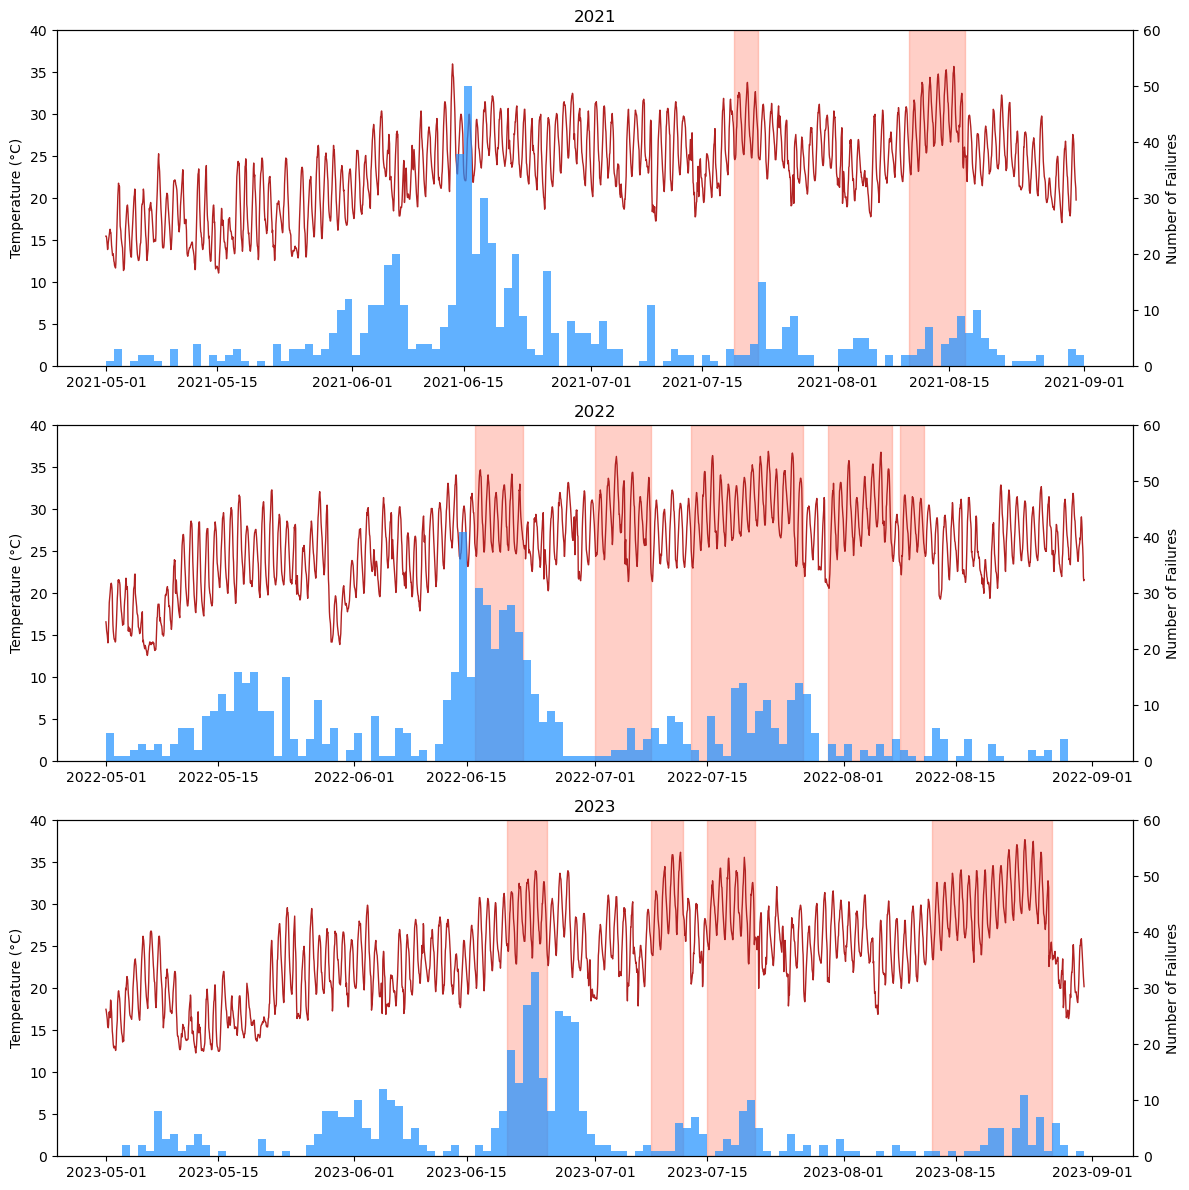

In [ ]:
hv=detect_heatwave(obs_data, T_threshold=32, N=3)
plot_timeseries_heatwave(obs_data, guasti, hv)

In [ ]:
def plot_temperature_timeseries(obs_data, start_date, end_date):
    """
    Plots the timeseries of temperature for each station on the same plot.

    Parameters:
    obs_data (DataFrame): DataFrame containing temperature data with columns REF_TIME, LATITUDE, LONGITUDE, ALTITUDE, STATION_NAME, VALUE.
    start_date (str): Start date in 'YYYY-MM-DD' format.
    end_date (str): End date in 'YYYY-MM-DD' format.

    Returns:
    None: Displays the plot.
    """
    # Filter data for the specified date range
    filtered_data = obs_data[(obs_data['REF_TIME'] >= start_date) & (obs_data['REF_TIME'] <= end_date)]
    
    # Plot the timeseries for each station
    plt.figure(figsize=(15, 8))
    for station_name, station_data in filtered_data.groupby('STATION_NAME'):
        plt.plot(station_data['REF_TIME'], station_data['VALUE'], label=station_name)
    
    # Add labels, legend, and title
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Temperature (°C)', fontsize=12)
    plt.title('Temperature Timeseries for Each Station', fontsize=14)
    plt.legend(loc='upper right', fontsize=10, title='Station Name')
    plt.grid(True)
    plt.tight_layout()
    plt.show()



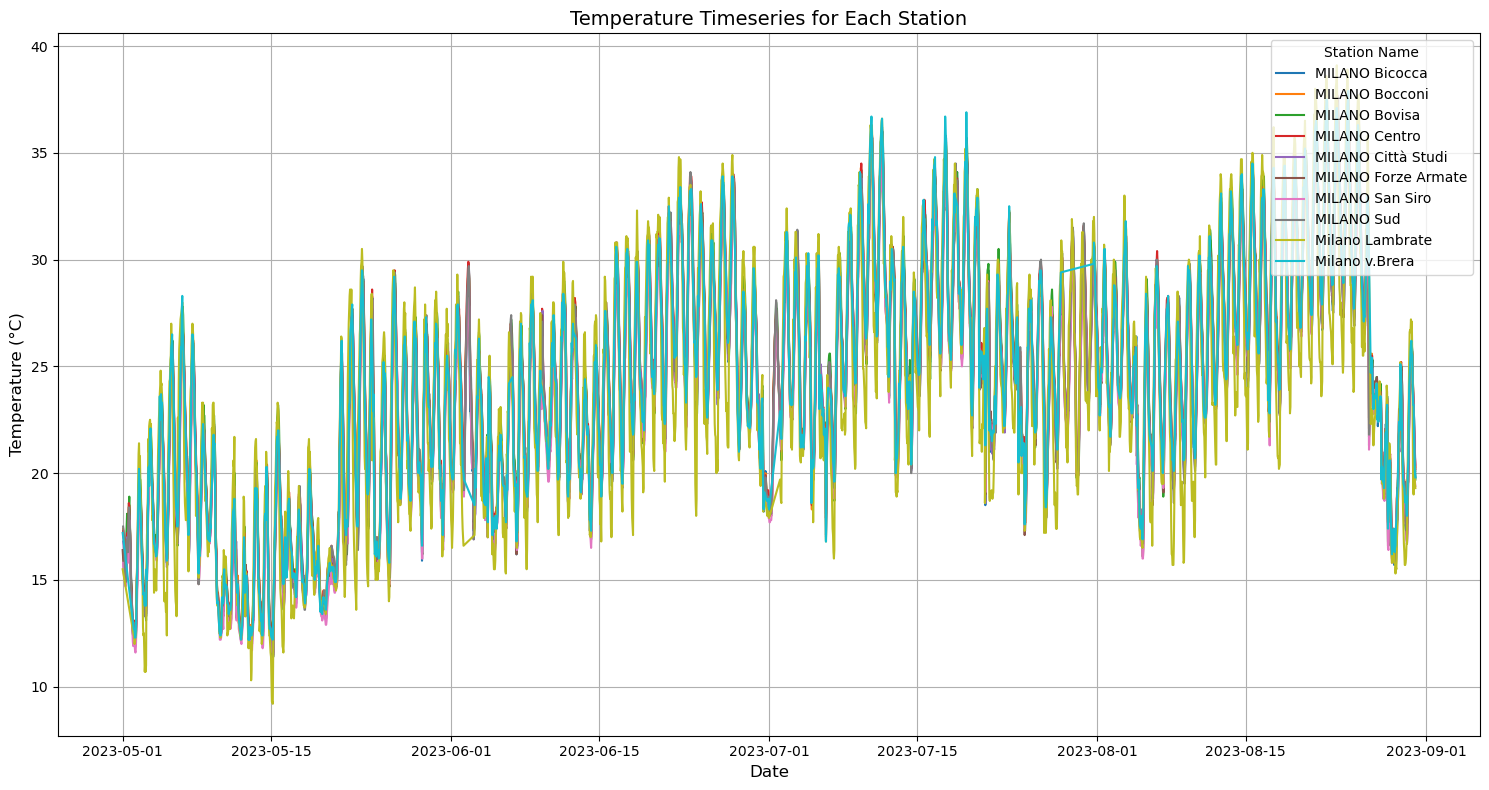

In [ ]:
plot_temperature_timeseries(obs_data, '2023-05-01', '2023-08-31')

In [ ]:
def load_loc_tratti(filename):
    """
    Load the CSV file containing the tratti data and format the 'SHAPE' column.

    Parameters:
    filename (str): Path to the CSV file.
    guasti_ds (DataFrame): DataFrame containing the guasti data.

    Returns:
    DataFrame: DataFrame containing the tratti data with formatted 'SHAPE' column.
    """
    # Load the CSV file
    loc_tratti = pd.read_csv(filename, sep=',')

    # Format the 'SHAPE' column to extract a list of (lat, lon) coordinates
    def extract_coordinates(shape):
        # Safely evaluate the string to convert it into a Python dictionary
        shape_data = ast.literal_eval(shape)
        coordinates = shape_data.get("coordinates", [])
        # Flatten the list of coordinates and convert to (lat, lon) tuples
        return [(coord[1], coord[0]) for coord in coordinates[0]]

    # Apply the extraction function to the 'SHAPE' column
    loc_tratti['SHAPE'] = loc_tratti['SHAPE'].apply(extract_coordinates)

    # create a new column with the center of the coordinates for each row
    loc_tratti['CENTER'] = loc_tratti['SHAPE'].apply(lambda x: (np.mean([coord[0] for coord in x]), np.mean([coord[1] for coord in x])))

    # Create a GeoDataFrame with the geometry column
    loc_tratti = gpd.GeoDataFrame(
        loc_tratti,
        geometry=gpd.points_from_xy(
            [center[1] for center in loc_tratti['CENTER']],  # Longitude
            [center[0] for center in loc_tratti['CENTER']]   # Latitude
        ),
        crs="EPSG:32632"  # Define the CRS
    )

    # Convert the geometry to WGS84 (EPSG:4326)
    loc_tratti = loc_tratti.to_crs(epsg=4326)

    return loc_tratti


In [ ]:
tratti_ds = load_loc_tratti('cabine_secondarie_mi_cleaned.csv')

In [ ]:
def load_loc_primarie(filename):
    """
    Load the CSV file containing the primary cabin data and format the loc column.

    Parameters:
    filename (str): Path to the CSV file.
    guasti_ds (DataFrame): DataFrame containing the guasti data.

    Returns:
    DataFrame: DataFrame containing the primary cabin data with formatted loc column.
    """
    # Load the CSV file
    loc_primarie = pd.read_csv(filename, sep=',')

    # create a geometry column from the coordinates in WGS_LAT and WGS_LONG
    loc_primarie['geometry'] = gpd.points_from_xy(loc_primarie['WGS_LONG'], loc_primarie['WGS_LAT'])

    # geodataframe
    loc_primarie = gpd.GeoDataFrame(loc_primarie, geometry='geometry', crs="EPSG:4326")

    return loc_primarie


In [ ]:
primarie_ds = load_loc_primarie('cabine_primarie_mi_cleaned.csv')

In [ ]:
display(tratti_ds.head())
print('Number of tratti:', len(tratti_ds))


,COD_CABINA,SHAPE,SOTTOTIPO,TENSIONEESERCIZIO,STATO,GESTIONE,MRID,COMUNEAPPARTENENZA,CENTER,geometry
0,CABEE-A06118,"[(5033909.0618, 507292.764), (5033912.0099, 50...",0,23000,InEsercizio,UNARETI,ELECBSEP0001008304,MILANO,"(5033912.9996, 507294.34328000003)",POINT (9.09330 45.45871)
1,E04441,"[(5038305.1788, 518260.9049), (5038300.0986, 5...",0,23000,InEsercizio,UNARETI,ELECBSEP0001002360,MILANO,"(5038305.3536600005, 518265.14394)",POINT (9.23378 45.49804)
2,E03798,"[(5039306.0546, 512311.5795), (5039313.5545, 5...",0,23000,InEsercizio,UNARETI,ELECBSEP0001001755,MILANO,"(5039309.06708, 512308.59206000005)",POINT (9.15757 45.50721)
3,A01256,"[(5040370.9202, 516702.0038), (5040373.6684, 5...",0,23000,InEsercizio,UNARETI,ELECBSEP0001006624,MILANO,"(5040369.234259998, 516698.07944)",POINT (9.21379 45.51666)
4,A01792,"[(5035224.4751, 517382.3929), (5035232.0498, 5...",0,23000,InEsercizio,UNARETI,ELECBSEP0001006535,MILANO,"(5035227.44928, 517379.33087999996)",POINT (9.22233 45.47036)


Number of tratti: 6373


In [ ]:
display(primarie_ds.head())

,SIGLA,COD_CABINA,SOTTOTIPO,GESTIONE,STATO,COMPETENZA,PROPRIETA,X,Y,WGS_LAT,WGS_LONG,geometry
0,AS,ASSAGO,0,ENEL-DISTRIBUZIONE,InEsercizio,Milano,ENEL-DISTRIBUZIONE,510472.52650,5.027244e+06,45.398631,9.133805,POINT (9.13381 45.39863)
1,BA,BASSI,1,UNARETI,InEsercizio,Milano,AEM,514742.47745,5.037867e+06,45.494178,9.188680,POINT (9.18868 45.49418)
2,BM,MARCELLO,0,UNARETI,InEsercizio,Milano,AEM,516180.35930,5.036279e+06,45.479856,9.207030,POINT (9.20703 45.47986)
3,BR,BRUNELLESCHI,1,UNARETI,InEsercizio,Milano,AEM,511166.66680,5.032684e+06,45.447593,9.142798,POINT (9.14280 45.44759)
4,BS,BRUSUGLIO,0,ENEL-DISTRIBUZIONE,InEsercizio,Milano,ENEL-DISTRIBUZIONE,513345.71365,5.042806e+06,45.538663,9.170938,POINT (9.17094 45.53866)


In [ ]:
def plot_cabin_heatmap(tratti_ds, shapefile_path):
    """
    Plots a map with the contour of the Comune di Milano and overlays a heatmap
    with tile size 0.1 degrees in latitude and longitude. The value of each tile
    represents the number of cabins located in that tile.

    Parameters:
    tratti_ds (GeoDataFrame): GeoDataFrame containing the tratti data with geometry for secondary cabins.
    shapefile_path (str): Path to the shapefile of the Comune di Milano.

    Returns:
    None: Displays the map.
    """
    # Extract the latitude and longitude of the cabins
    lats = tratti_ds.geometry.y
    lons = tratti_ds.geometry.x

    # Define the grid size (tile size)
    grid_size = 0.01

    # Create a 2D histogram (heatmap) of the cabin locations
    lon_min, lon_max = lons.min(), lons.max()
    lat_min, lat_max = lats.min(), lats.max()
    lon_bins = np.arange(lon_min, lon_max + grid_size, grid_size)
    lat_bins = np.arange(lat_min, lat_max + grid_size, grid_size)
    heatmap, lon_edges, lat_edges = np.histogram2d(lons, lats, bins=[lon_bins, lat_bins])

    # Create a map with Cartopy
    fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent([lon_min - 0.05, lon_max + 0.05, lat_min - 0.05, lat_max + 0.05], crs=ccrs.PlateCarree())

    # Use Google Maps tiles as the background
    google_tiles = cimgt.GoogleTiles()
    ax.add_image(google_tiles, 10, zorder=0)

    # Plot the heatmap
    lon_centers = (lon_edges[:-1] + lon_edges[1:]) / 2
    lat_centers = (lat_edges[:-1] + lat_edges[1:]) / 2
    mesh = ax.pcolormesh(lon_centers, lat_centers, heatmap.T, cmap='Blues', alpha=0.6, shading='auto', transform=ccrs.PlateCarree())

    # Add a colorbar
    cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
    cbar.set_label('Number of Cabins', fontsize=12)

    # Plot the contour of the Comune di Milano
    milano_shp = shapereader.Reader(shapefile_path)
    milano_geom = [record.geometry for record in milano_shp.records()]
    milano_gdf = gpd.GeoDataFrame(geometry=milano_geom, crs='EPSG:3003')  # Roma40 Gauss-Boaga
    milano_gdf = milano_gdf.to_crs(epsg=4326)  # Convert to WGS84
    for geom in milano_gdf.geometry:
        ax.add_geometries([geom], crs=ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=2)

    # Add title and gridlines
    ax.set_title('Heatmap of Cabins in Comune di Milano', fontsize=16)
    ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

    # Show the map
    plt.show()

    return lon_edges, lat_edges, heatmap

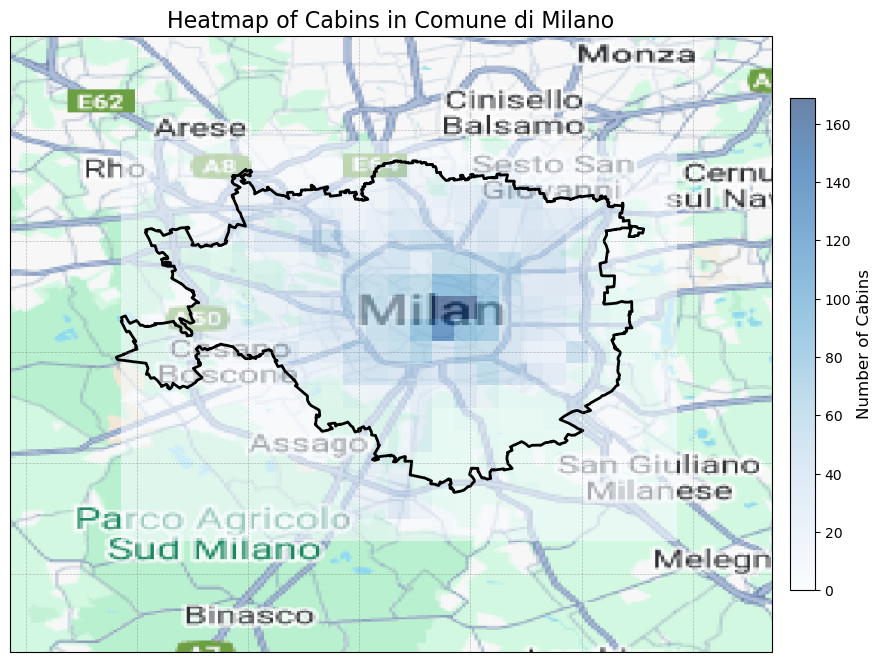

In [ ]:
grid_lon_edges, grid_lat_edges, heatmap_cabin_density = plot_cabin_heatmap(tratti_ds, "shapefiles/L090102_ComuneMilano.shp")

In [ ]:
print('Grid Lon Edges:', len(grid_lon_edges))
print('Grid Lat Edges:', len(grid_lat_edges))
print('Heatmap Cabin Density:', np.shape(heatmap_cabin_density))

Grid Lon Edges: 26
Grid Lat Edges: 19
Heatmap Cabin Density: (25, 18)


In [ ]:
def plot_stations(tratti_ds, primarie_ds):
    """
    Plots the average temperature from all stations between two dates as colored dots on a map using matplotlib and cartopy.
    Also localizes each secondary cabin of the grid from the tratti dataset with cross markers.

    Parameters:
    obs_data (DataFrame): DataFrame containing temperature data with columns REF_TIME, LATITUDE, LONGITUDE, ALTITUDE, STATION_NAME, VALUE.
    tratti_ds (GeoDataFrame): GeoDataFrame containing the tratti data with geometry for secondary cabins.
    start_date (str): Start date in 'YYYY-MM-DD' format.
    end_date (str): End date in 'YYYY-MM-DD' format.

    Returns:
    None: Displays the map.
    """
    ntratti = len(tratti_ds)
    nprimarie = len(primarie_ds)

    # Use Google Maps tiles as the background
    google_tiles = cimgt.GoogleTiles()

    # Create a map with Cartopy
    fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent([
        tratti_ds.geometry.x.min() - 0.05, tratti_ds.geometry.x.max() + 0.05,
        tratti_ds.geometry.y.min() - 0.05, tratti_ds.geometry.y.max() + 0.05
    ], crs=ccrs.PlateCarree())

    # Add Google Maps tiles
    ax.add_image(google_tiles, 12)  # The second argument is the zoom level
    
    ## also plot the Milano comune shapefile, CRS is ETRF00
    milano_shp = shapereader.Reader("shapefiles/L090102_ComuneMilano.shp")
    milano_geom = [record.geometry for record in milano_shp.records()]
    milano_gdf = gpd.GeoDataFrame(geometry=milano_geom, crs='EPSG:3003') # Roma40 Gauss-Boaga 
    milano_gdf = milano_gdf.to_crs(epsg=4326)
    for geom in milano_gdf.geometry:
        ax.add_geometries([geom], crs=ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=2)

   
    for _, row in tratti_ds.iterrows():
        ax.plot(
            row.geometry.x, row.geometry.y, marker='.', color='dodgerblue', markersize=2,
            transform=ccrs.PlateCarree(), label=f'Secondary Cabins: {ntratti}' if _ == 0 else "", zorder=1
        )

    # plot the primary cabins as squares
    for _, row in primarie_ds.iterrows():
        ax.plot(
            row.geometry.x, row.geometry.y, marker='s', color='darkolivegreen', markersize=5,
            transform=ccrs.PlateCarree(), label=f'Primary Cabins: {nprimarie}' if _ == 0 else "", zorder=1
        )

    ax.legend(loc='lower left', fontsize=10)

    
    # Show the map
    plt.show()


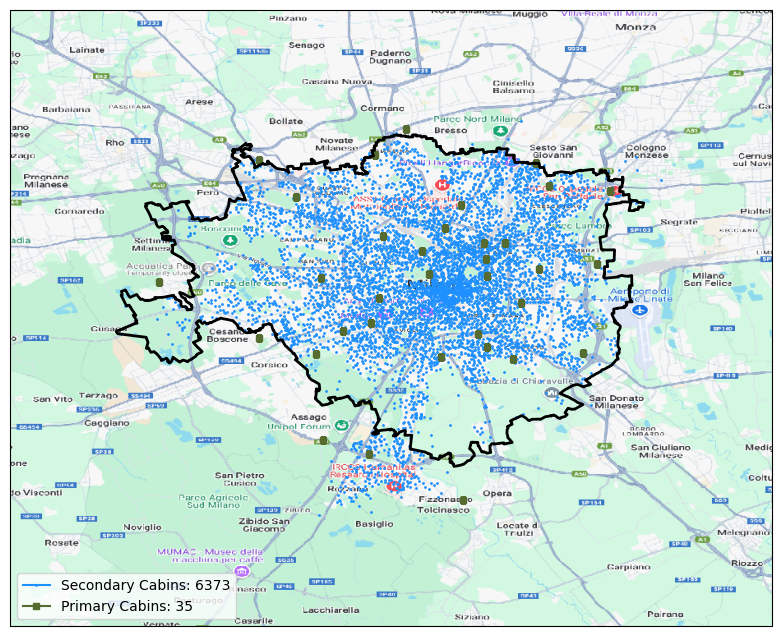

In [ ]:
plot_stations(tratti_ds, primarie_ds)

In [ ]:
def plot_station_temp_cartopy(obs_data, tratti_ds, guasti_ds, grid_lon_edges, grid_lat_edges, dates, normalize=False, range_temp=(20, 25), delay=dt.timedelta(days=0)):
    """
    Plots the average temperature from all stations between two dates as colored dots on a map using matplotlib and cartopy.
    Also aggregates secondary cabins into grid cells and plots a heatmap.

    Parameters:
    obs_data (DataFrame): DataFrame containing temperature data with columns REF_TIME, LATITUDE, LONGITUDE, ALTITUDE, STATION_NAME, VALUE.
    tratti_ds (GeoDataFrame): GeoDataFrame containing the tratti data with geometry for secondary cabins.
    guasti_ds (DataFrame): DataFrame containing guasti data.
    grid_lon_edges (array): Longitude edges of the grid for the heatmap.
    grid_lat_edges (array): Latitude edges of the grid for the heatmap.
    start_date (str): Start date in 'YYYY-MM-DD' format.
    end_date (str): End date in 'YYYY-MM-DD' format.

    Returns:
    None: Displays the map.
    """
    # Filter the guasti and obs_data dataset for the specified date range
    guasti_ds = guasti_ds[guasti_ds['Causegroup']=='joint']
    guasti_ds['Data di guasto'] = pd.to_datetime(guasti_ds['Data di guasto'], format='%d/%m/%Y', errors='coerce')
    guasti_ds['in datelist']= False

    for date in guasti_ds['Data di guasto']:
        for date_from_list in dates:
            date_with_delay = date_from_list + delay
            if (date.year == date_with_delay.year) and (date.month == date_with_delay.month) and (date.day == date_with_delay.day):
                guasti_ds.loc[guasti_ds['Data di guasto'] == date, 'in datelist'] = True
    guasti_ds = guasti_ds[guasti_ds['in datelist'] == True]
    print('Number of guasti for the dates:', len(guasti_ds))

    obs_data['in datelist'] = False
    obs_data['REF_TIME'] = pd.to_datetime(obs_data['REF_TIME'], format='%Y-%m-%dT%H:%M:%S', errors='coerce')
    for date in obs_data['REF_TIME']:
         for date_from_list in dates:
            if (date.year == date_from_list.year) and (date.month == date_from_list.month) and (date.day == date_from_list.day):
                obs_data.loc[obs_data['REF_TIME'] == date, 'in datelist'] = True
    obs_data = obs_data[obs_data['in datelist'] == True]

    # Count the number of guasti for each cabin
    tratti_ds['COD_CABINA'] = tratti_ds['COD_CABINA'].astype(str).str.strip()
    guasti_ds['da cabina'] = guasti_ds['da cabina'].astype(str).str.strip()
    guasti_ds['a cabina'] = guasti_ds['a cabina'].astype(str).str.strip()
    
    tratti_ds['GUASTI'] = tratti_ds.apply(
        lambda x: max(0, guasti_ds[(guasti_ds['da cabina'] == x['COD_CABINA']) | (guasti_ds['a cabina'] == x['COD_CABINA'])].shape[0]),
        axis=1
    )
    tratti_ds['GUASTI'] = tratti_ds['GUASTI'].astype(int)
    tratti_ds = tratti_ds[tratti_ds['GUASTI'] > 0]
    print('Number of tratti with guasti:', len(tratti_ds['GUASTI']))

    # compute lons, lats 
    lons = np.multiply(tratti_ds.geometry.x, tratti_ds['GUASTI'])
    lats = np.multiply(tratti_ds.geometry.y, tratti_ds['GUASTI'])
    lon_min, lon_max = grid_lon_edges[0], grid_lon_edges[-1]
    lat_min, lat_max = grid_lat_edges[0], grid_lat_edges[-1]
    
    # Create a 2D histogram (heatmap) of the cabin locations
    heatmap, _, _ = np.histogram2d(lons, lats, bins=[grid_lon_edges, grid_lat_edges])
    
    if normalize:
        # divide the failure heatmaps by the number of stations in the grid (heatmap_cabin_density)
        heatmap = np.where(heatmap_cabin_density > 0, heatmap / heatmap_cabin_density, 0)  # Avoid division by zero
        heatmap = np.nan_to_num(heatmap)  # Replace NaN values with 0
        heatmap = heatmap / np.max(heatmap) 
        vmax_heatmap = 1
    else:
        vmax_heatmap = 15

    # Filter data for the specified date range
    filtered_data = obs_data[obs_data['REF_TIME'].isin(dates)]

    # Group by station and calculate the average temperature
    avg_temp_by_station = filtered_data.groupby(['STATION_NAME', 'LATITUDE', 'LONGITUDE']).agg({'VALUE': 'mean'}).reset_index()

    # Normalize temperature values for colormap
    norm = mcolors.Normalize(vmin=range_temp[0], vmax=range_temp[1])
    cmap = plt.get_cmap('Reds')

    # Create a map with Cartopy
    fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent([
        lon_min - 0.01, lon_max + 0.01,
        lat_min - 0.01, lat_max + 0.01
    ], crs=ccrs.PlateCarree())

    # Add Google Maps tiles
    #google_tiles = cimgt.GoogleTiles()
    #ax.add_image(google_tiles, 12) 

    # Plot the heatmap
    lon_centers = (grid_lon_edges[:-1] + grid_lon_edges[1:]) / 2
    lat_centers = (grid_lat_edges[:-1] + grid_lat_edges[1:]) / 2
    mesh = ax.pcolormesh(
        lon_centers, lat_centers, heatmap.T, cmap='Blues', alpha=0.6, shading='auto', transform=ccrs.PlateCarree(), vmin=0, vmax=vmax_heatmap,
    )

    # Add a colorbar for the heatmap
    cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
    cbar.set_label('Number of Failures', fontsize=12)

    # Plot temperature stations as colored dots
    scatter = ax.scatter(
        avg_temp_by_station['LONGITUDE'], avg_temp_by_station['LATITUDE'],
        c=avg_temp_by_station['VALUE'], cmap=cmap, norm=norm, s=50, edgecolor='black',
        transform=ccrs.PlateCarree(), label='Temperature Stations', zorder=2,
    )

    # Add a colorbar for temperature
    cbar_temp = plt.colorbar(scatter, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
    cbar_temp.set_label('Average Daily Temperature (°C)', fontsize=12)

    # Plot the contour of the Comune di Milano
    milano_shp = shapereader.Reader("shapefiles/L090102_ComuneMilano.shp")
    milano_geom = [record.geometry for record in milano_shp.records()]
    milano_gdf = gpd.GeoDataFrame(geometry=milano_geom, crs='EPSG:3003')  # Roma40 Gauss-Boaga
    milano_gdf = milano_gdf.to_crs(epsg=4326)  # Convert to WGS84
    for geom in milano_gdf.geometry:
        ax.add_geometries([geom], crs=ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=2)

    # Show the map
    plt.show()

    return heatmap

In [ ]:
dates_summer23 = pd.date_range(start='2023-05-01', end='2023-08-31', freq='d').tz_localize('UTC')
dates_summer22 = pd.date_range(start='2022-05-01', end='2022-08-31', freq='d').tz_localize('UTC')
dates_summer21 = pd.date_range(start='2021-05-01', end='2021-08-31', freq='d').tz_localize('UTC')
all_dates = pd.DatetimeIndex(pd.concat([pd.Series(dates_summer21), pd.Series(dates_summer22), pd.Series(dates_summer23)], ignore_index=True))
plot_station_temp_cartopy(obs_data, tratti_ds, guasti, grid_lon_edges, grid_lat_edges, dates=all_dates, normalize=False, range_temp=(20, 25))

NameError: name 'plot_station_temp_cartopy' is not defined

In [ ]:
hv = [hv for hv in hv if hv[0]]
dates_hv=pd.DatetimeIndex([pd.Timestamp(h).tz_localize('UTC') for hh in hv for h in hh])
heatmap_hv = plot_station_temp_cartopy(obs_data, tratti_ds, guasti, grid_lon_edges, grid_lat_edges, dates=dates_hv, normalize=False, range_temp=(26, 28))

NameError: name 'hv' is not defined

In [ ]:
heatmap_hv_normalized= plot_station_temp_cartopy(obs_data, tratti_ds, guasti, grid_lon_edges, grid_lat_edges, dates=dates_hv, normalize=True, range_temp=(26, 28))

NameError: name 'plot_station_temp_cartopy' is not defined

In [ ]:
heatmap_hv_d1 = plot_station_temp_cartopy(obs_data, tratti_ds, guasti, grid_lon_edges, grid_lat_edges, dates=dates_hv, normalize=False, range_temp=(26, 28), delay=dt.timedelta(days=1))
heatmap_hv_d2 = plot_station_temp_cartopy(obs_data, tratti_ds, guasti, grid_lon_edges, grid_lat_edges, dates=dates_hv, normalize=False, range_temp=(26, 28), delay=dt.timedelta(days=2))

NameError: name 'plot_station_temp_cartopy' is not defined

C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_25916\2757899627.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  guasti_ds['Data di guasto'] = pd.to_datetime(guasti_ds['Data di guasto'], format='%d/%m/%Y', errors='coerce')
C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_25916\2757899627.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  guasti_ds['in datelist']= False


Number of guasti for the dates: 499
Number of tratti with guasti: 661


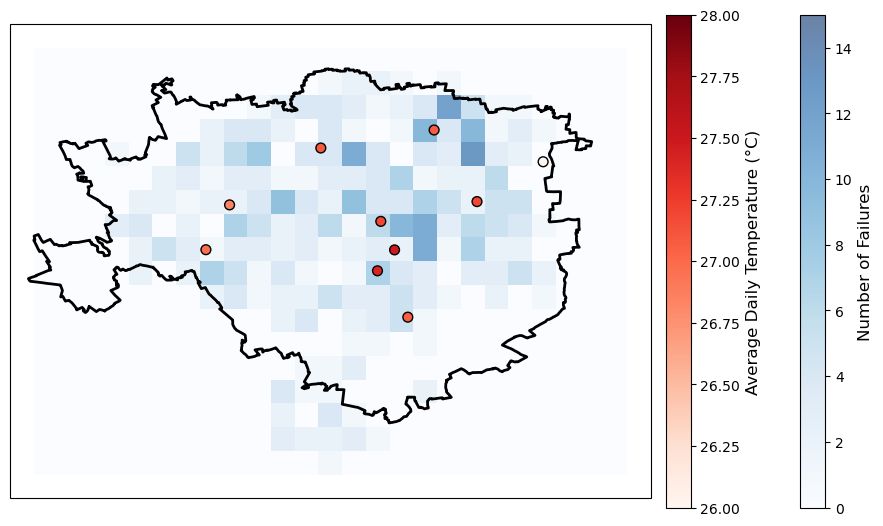

C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_25916\2757899627.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  guasti_ds['Data di guasto'] = pd.to_datetime(guasti_ds['Data di guasto'], format='%d/%m/%Y', errors='coerce')
C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_25916\2757899627.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  guasti_ds['in datelist']= False


Number of guasti for the dates: 471
Number of tratti with guasti: 617


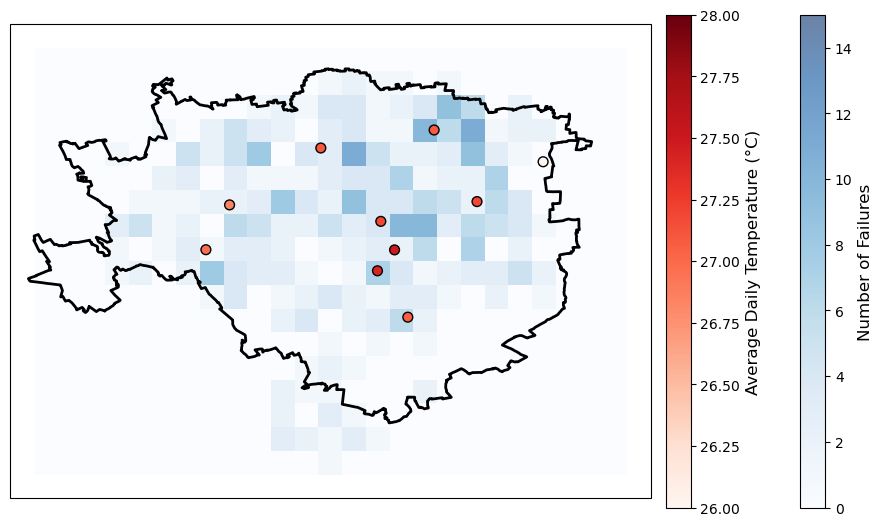

In [ ]:
heatmap_hv_d3 = plot_station_temp_cartopy(obs_data, tratti_ds, guasti, grid_lon_edges, grid_lat_edges, dates=dates_hv, normalize=False, range_temp=(26, 28), delay=dt.timedelta(days=3))
heatmap_hv_d4 = plot_station_temp_cartopy(obs_data, tratti_ds, guasti, grid_lon_edges, grid_lat_edges, dates=dates_hv, normalize=False, range_temp=(26, 28), delay=dt.timedelta(days=4))

C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_25916\2757899627.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  guasti_ds['Data di guasto'] = pd.to_datetime(guasti_ds['Data di guasto'], format='%d/%m/%Y', errors='coerce')
C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_25916\2757899627.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  guasti_ds['in datelist']= False


Number of guasti for the dates: 425
Number of tratti with guasti: 567


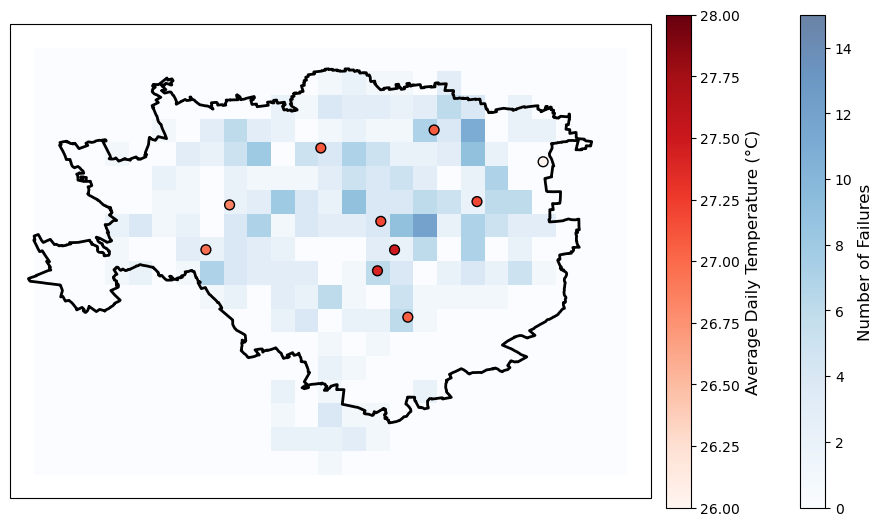

C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_25916\2757899627.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  guasti_ds['Data di guasto'] = pd.to_datetime(guasti_ds['Data di guasto'], format='%d/%m/%Y', errors='coerce')
C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_25916\2757899627.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  guasti_ds['in datelist']= False


Number of guasti for the dates: 374
Number of tratti with guasti: 492


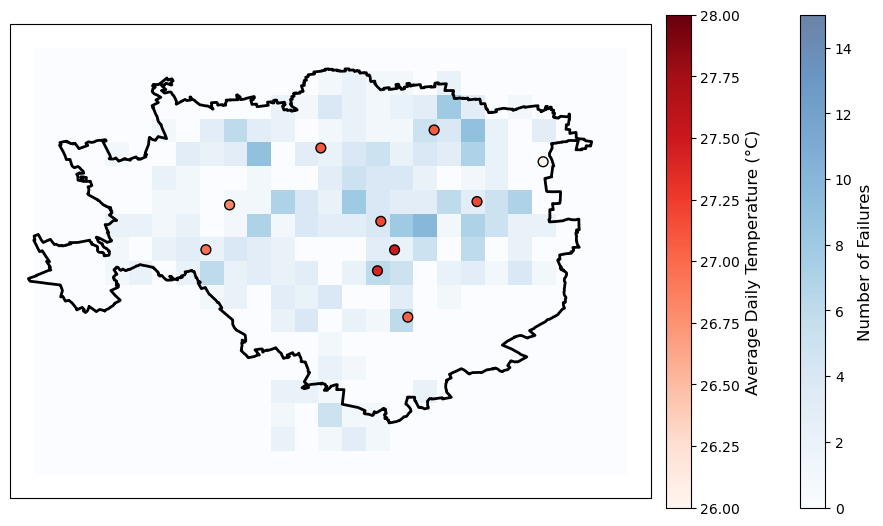

In [ ]:
heatmap_hv_d5 = plot_station_temp_cartopy(obs_data, tratti_ds, guasti, grid_lon_edges, grid_lat_edges, dates=dates_hv, normalize=False, range_temp=(26, 28), delay=dt.timedelta(days=5))
heatmap_hv_d6 = plot_station_temp_cartopy(obs_data, tratti_ds, guasti, grid_lon_edges, grid_lat_edges, dates=dates_hv, normalize=False, range_temp=(26, 28), delay=dt.timedelta(days=6))

Number of non hv dates: 291
Number of hv dates: 78
Number of all dates: 369


C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_25916\3576265554.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  guasti_ds['Data di guasto'] = pd.to_datetime(guasti_ds['Data di guasto'], format='%d/%m/%Y', errors='coerce')
C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_25916\3576265554.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  guasti_ds['in datelist']= False


Number of guasti for the dates: 1180
Number of tratti with guasti: 1322


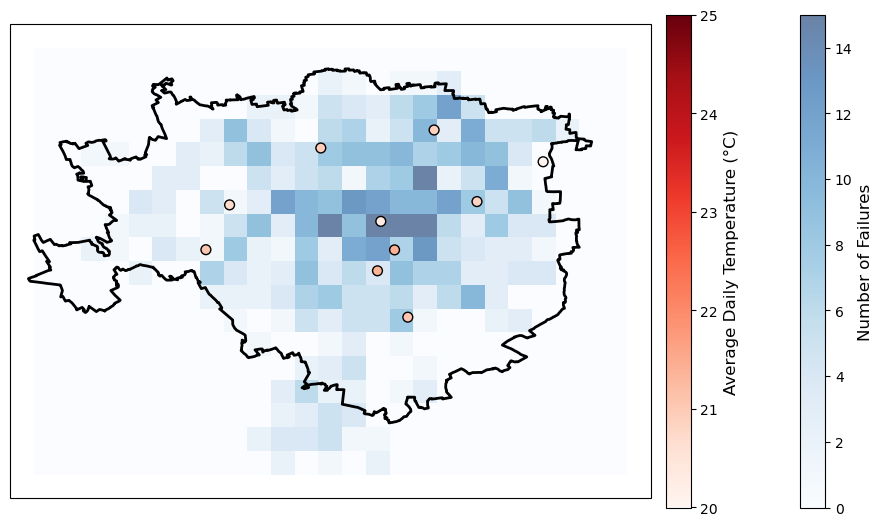

In [ ]:
nonhv = all_dates[~all_dates.isin(dates_hv)]
print('Number of non hv dates:', len(nonhv))
print('Number of hv dates:', len(dates_hv))
print('Number of all dates:', len(all_dates))
heatmap_nonhv = plot_station_temp_cartopy(obs_data, tratti_ds, guasti, grid_lon_edges, grid_lat_edges, dates=nonhv, normalize=False, range_temp=(20, 25))

C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_25916\2757899627.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  guasti_ds['Data di guasto'] = pd.to_datetime(guasti_ds['Data di guasto'], format='%d/%m/%Y', errors='coerce')
C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_25916\2757899627.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  guasti_ds['in datelist']= False


Number of guasti for the dates: 1156
Number of tratti with guasti: 1305


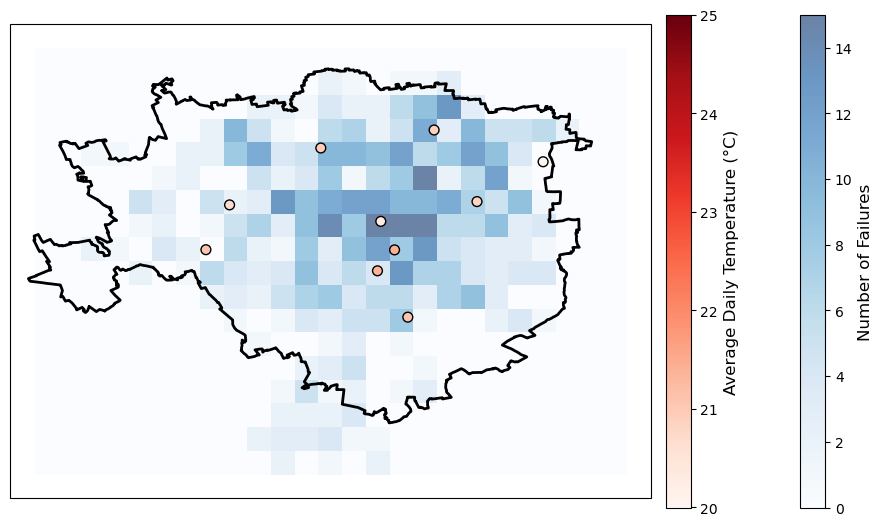

C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_25916\2757899627.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  guasti_ds['Data di guasto'] = pd.to_datetime(guasti_ds['Data di guasto'], format='%d/%m/%Y', errors='coerce')
C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_25916\2757899627.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  guasti_ds['in datelist']= False


Number of guasti for the dates: 1126
Number of tratti with guasti: 1281


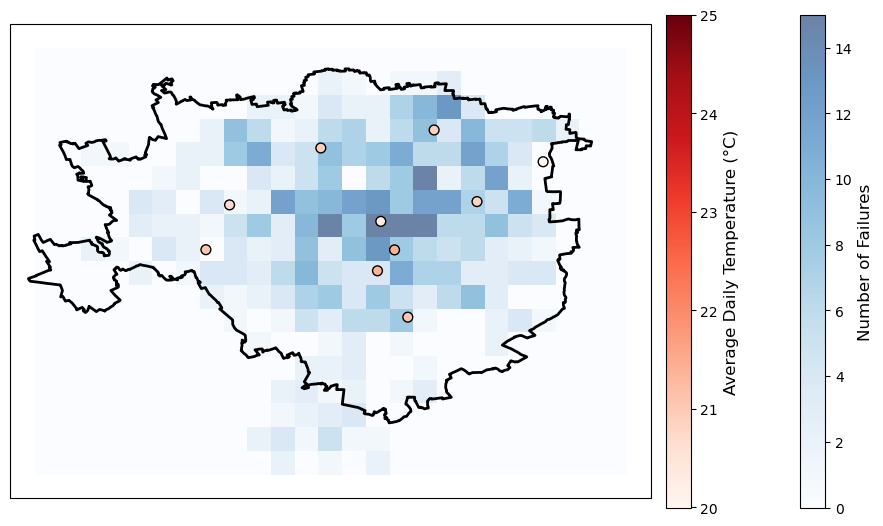

In [ ]:
heatmap_nonhv_d1 = plot_station_temp_cartopy(obs_data, tratti_ds, guasti, grid_lon_edges, grid_lat_edges, dates=nonhv, normalize=False, range_temp=(20, 25), delay=dt.timedelta(days=1))
heatmap_nonhv_d2 = plot_station_temp_cartopy(obs_data, tratti_ds, guasti, grid_lon_edges, grid_lat_edges, dates=nonhv, normalize=False, range_temp=(20, 25), delay=dt.timedelta(days=2))

C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_25916\2757899627.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  guasti_ds['Data di guasto'] = pd.to_datetime(guasti_ds['Data di guasto'], format='%d/%m/%Y', errors='coerce')
C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_25916\2757899627.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  guasti_ds['in datelist']= False


Number of guasti for the dates: 1144
Number of tratti with guasti: 1313


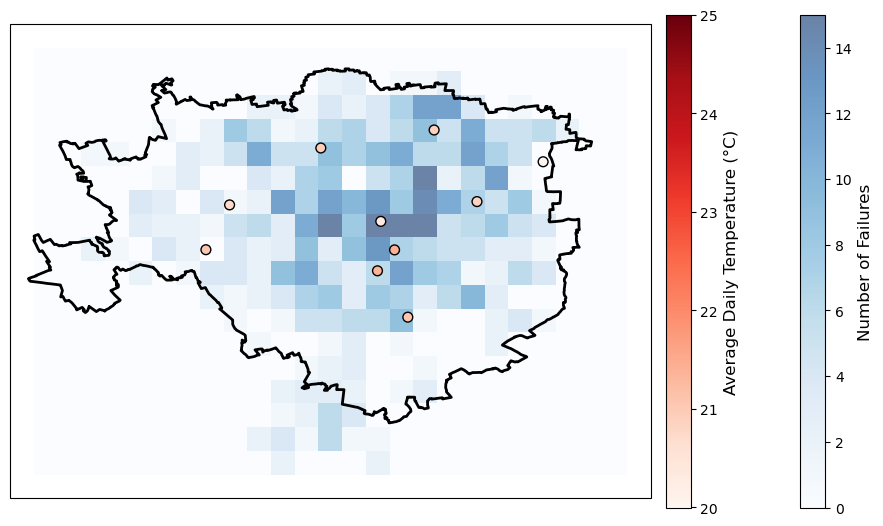

C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_25916\2757899627.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  guasti_ds['Data di guasto'] = pd.to_datetime(guasti_ds['Data di guasto'], format='%d/%m/%Y', errors='coerce')
C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_25916\2757899627.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  guasti_ds['in datelist']= False


Number of guasti for the dates: 1169
Number of tratti with guasti: 1327


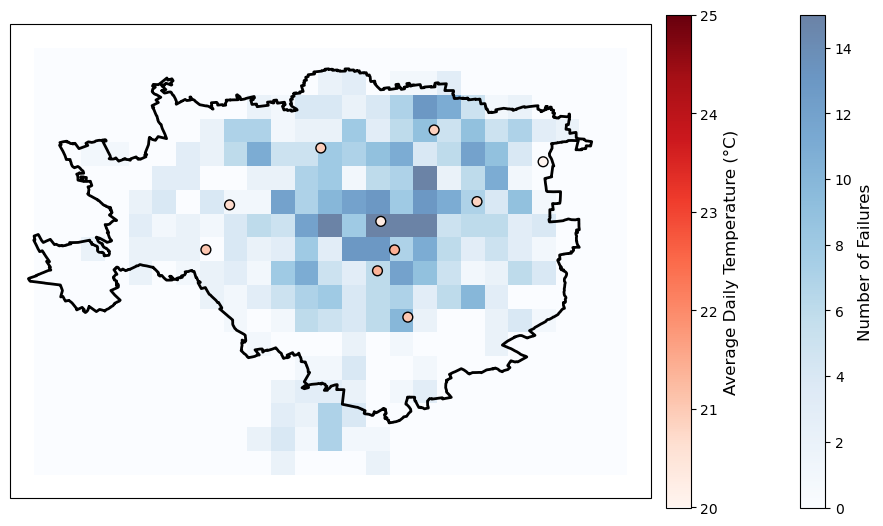

In [ ]:
heatmap_nonhv_d3 = plot_station_temp_cartopy(obs_data, tratti_ds, guasti, grid_lon_edges, grid_lat_edges, dates=nonhv, normalize=False, range_temp=(20, 25), delay=dt.timedelta(days=3))
heatmap_nonhv_d4 = plot_station_temp_cartopy(obs_data, tratti_ds, guasti, grid_lon_edges, grid_lat_edges, dates=nonhv, normalize=False, range_temp=(20, 25), delay=dt.timedelta(days=4))

C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_25916\2757899627.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  guasti_ds['Data di guasto'] = pd.to_datetime(guasti_ds['Data di guasto'], format='%d/%m/%Y', errors='coerce')
C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_25916\2757899627.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  guasti_ds['in datelist']= False


Number of guasti for the dates: 1208
Number of tratti with guasti: 1352


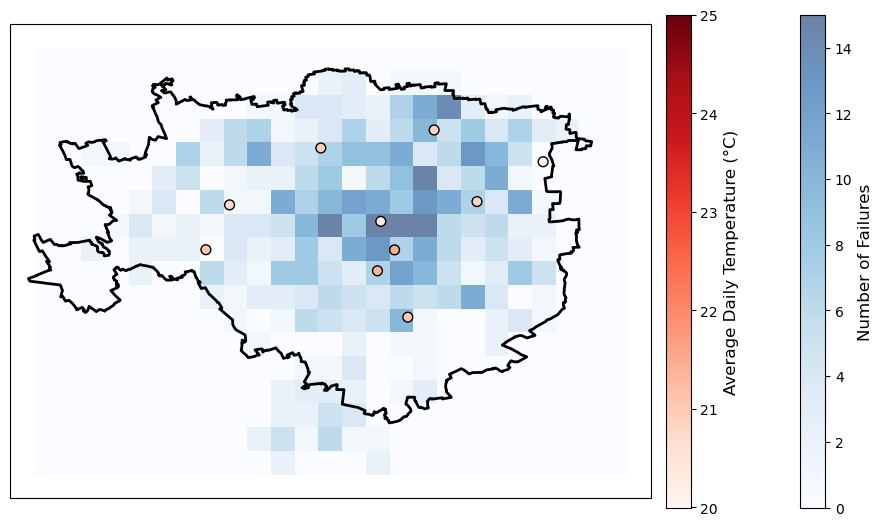

C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_25916\2757899627.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  guasti_ds['Data di guasto'] = pd.to_datetime(guasti_ds['Data di guasto'], format='%d/%m/%Y', errors='coerce')
C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_25916\2757899627.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  guasti_ds['in datelist']= False


Number of guasti for the dates: 1255
Number of tratti with guasti: 1407


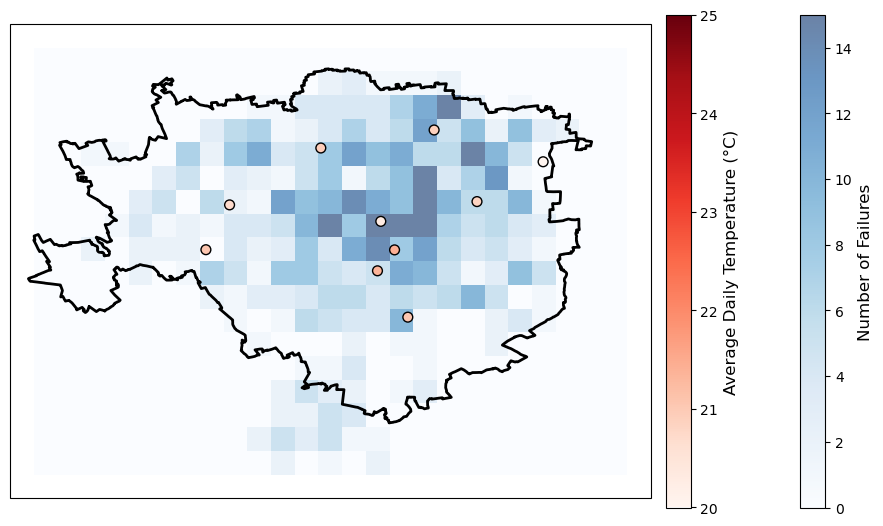

In [ ]:
heatmap_nonhv_d5 = plot_station_temp_cartopy(obs_data, tratti_ds, guasti, grid_lon_edges, grid_lat_edges, dates=nonhv, normalize=False, range_temp=(20, 25), delay=dt.timedelta(days=5))
heatmap_nonhv_d6 = plot_station_temp_cartopy(obs_data, tratti_ds, guasti, grid_lon_edges, grid_lat_edges, dates=nonhv, normalize=False, range_temp=(20, 25), delay=dt.timedelta(days=6))

C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_25916\4263207812.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  guasti_ds['Data di guasto'] = pd.to_datetime(guasti_ds['Data di guasto'], format='%d/%m/%Y', errors='coerce')
C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_25916\4263207812.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  guasti_ds['in datelist']= False


Number of guasti for the dates: 1180
Number of tratti with guasti: 1322


C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_25916\4263207812.py:62: RuntimeWarning: invalid value encountered in divide
  heatmap = np.where(heatmap_cabin_density > 0, heatmap / heatmap_cabin_density, 0)  # Avoid division by zero


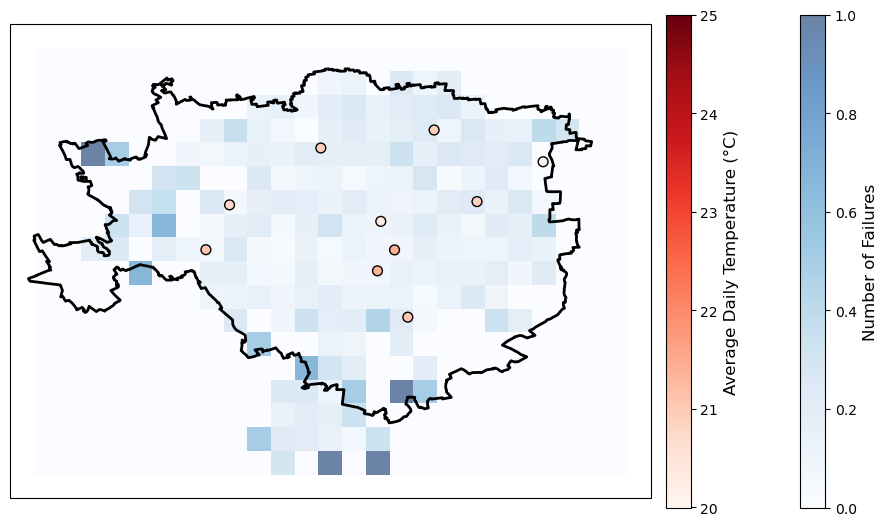

In [ ]:
heatmap_nonhv_normalized=plot_station_temp_cartopy(obs_data, tratti_ds, guasti, grid_lon_edges, grid_lat_edges, dates=nonhv, normalize=True, range_temp=(20, 25))

In [ ]:
def spatial_stats(cabin_density, heatmap_failures):
    # Flatten the heatmaps
    cabin_density_flat = heatmap_cabin_density.flatten()
    failures_flat = heatmap_failures.flatten()

    # Filter out grid cells where both values are zero
    valid_indices = (cabin_density_flat > 0) | (failures_flat > 0)
    cabin_density_filtered = cabin_density_flat[valid_indices]
    failures_filtered = failures_flat[valid_indices]

    # Compute Pearson and Spearman correlations
    pearson_corr, _ = pearsonr(cabin_density_filtered, failures_filtered)
    spearman_corr, _ = spearmanr(cabin_density_filtered, failures_filtered)

    print(f"Pearson Correlation: {pearson_corr}")
    print(f"Spearman Correlation: {spearman_corr}")

In [ ]:
print('no delay --- hv')
spatial_stats(heatmap_cabin_density, heatmap_hv)
print('no delay --- nonhv')
spatial_stats(heatmap_cabin_density, heatmap_nonhv)
print('delay 1 --- hv')
spatial_stats(heatmap_cabin_density, heatmap_hv_d1)
print('delay 1 --- nonhv')
spatial_stats(heatmap_cabin_density, heatmap_nonhv_d1)
print('delay 2 --- hv')
spatial_stats(heatmap_cabin_density, heatmap_hv_d2)
print('delay 2 --- nonhv')
spatial_stats(heatmap_cabin_density, heatmap_nonhv_d2)
print('delay 3 --- hv')
spatial_stats(heatmap_cabin_density, heatmap_hv_d3)
print('delay 3 --- nonhv')
spatial_stats(heatmap_cabin_density, heatmap_nonhv_d3)
print('delay 4 --- hv')
spatial_stats(heatmap_cabin_density, heatmap_hv_d4)
print('delay 4 --- nonhv')
spatial_stats(heatmap_cabin_density, heatmap_nonhv_d4)
print('delay 5 --- hv')
spatial_stats(heatmap_cabin_density, heatmap_hv_d5)
print('delay 5 --- nonhv')
spatial_stats(heatmap_cabin_density, heatmap_nonhv_d5)
print('delay 6 --- hv')
spatial_stats(heatmap_cabin_density, heatmap_hv_d6)
print('delay 6 --- nonhv')
spatial_stats(heatmap_cabin_density, heatmap_nonhv_d6)

no delay --- hv
Pearson Correlation: 0.630459281041414
Spearman Correlation: 0.7231522449071767
no delay --- nonhv
Pearson Correlation: 0.8310905620306617
Spearman Correlation: 0.8427710558276595
delay 1 --- hv
Pearson Correlation: 0.6359007635573435
Spearman Correlation: 0.7256518580123811
delay 1 --- nonhv
Pearson Correlation: 0.8229777922641277
Spearman Correlation: 0.8432031638910887
delay 2 --- hv
Pearson Correlation: 0.6458970722100863
Spearman Correlation: 0.7470492984305867
delay 2 --- nonhv
Pearson Correlation: 0.8227603143840996
Spearman Correlation: 0.8465922950913104
delay 3 --- hv
Pearson Correlation: 0.599979938391808
Spearman Correlation: 0.7203987583716663
delay 3 --- nonhv
Pearson Correlation: 0.8287497568148704
Spearman Correlation: 0.8499104432453997
delay 4 --- hv
Pearson Correlation: 0.5799776597800508
Spearman Correlation: 0.7028130889046023
delay 4 --- nonhv
Pearson Correlation: 0.828338688729171
Spearman Correlation: 0.8524356379002229
delay 5 --- hv
Pearson Cor

In [ ]:
def temperature_failure_stats(obs_data, heatmap_failures, grid_lon_edges, grid_lat_edges):
    """
    Compute the correlation between temperature at station locations and failures in the corresponding grid cells.

    Parameters:
    obs_data (DataFrame): DataFrame containing temperature data with columns REF_TIME, LATITUDE, LONGITUDE, VALUE.
    heatmap_failures (2D array): Heatmap of failures across the grid.
    grid_lon_edges (array): Longitude edges of the grid for the heatmap.
    grid_lat_edges (array): Latitude edges of the grid for the heatmap.

    Returns:
    None: Prints the Pearson and Spearman correlations.
    """
    # Initialize lists to store temperature and failure values
    station_temperatures = []
    station_failures = []

    # Iterate over each station in the temperature data
    for _, station in obs_data.groupby(['LATITUDE', 'LONGITUDE']):
    
        # Get the station's average temperature
        avg_temp = station['VALUE'].mean()

        # Find the grid cell corresponding to the station's location
        lon_idx = np.digitize(station['LONGITUDE'].iloc[0], grid_lon_edges) - 1
        lat_idx = np.digitize(station['LATITUDE'].iloc[0], grid_lat_edges) - 1

        # Ensure the indices are within bounds
        if 0 <= lon_idx < heatmap_failures.shape[1] and 0 <= lat_idx < heatmap_failures.shape[0]:
            # Get the number of failures in the corresponding grid cell
            failures = heatmap_failures[lat_idx, lon_idx]

            # Append the temperature and failure values
            station_temperatures.append(avg_temp)
            station_failures.append(failures)

    # Convert to numpy arrays
    station_temperatures = np.array(station_temperatures)
    station_failures = np.array(station_failures)

    # Compute Pearson and Spearman correlations
    pearson_corr, _ = pearsonr(station_temperatures, station_failures)
    spearman_corr, _ = spearmanr(station_temperatures, station_failures)

    # Print the results
    print(f"Pearson Correlation: {pearson_corr}")
    print(f"Spearman Correlation: {spearman_corr}")

In [ ]:
obs_data_hv = obs_data[obs_data['REF_TIME'].isin(dates_hv)]
obs_data_nonhv = obs_data[obs_data['REF_TIME'].isin(nonhv)]

print('hv --- no delay')
temperature_failure_stats(obs_data_hv, heatmap_hv, grid_lon_edges, grid_lat_edges)
print('nonhv --- no delay')
temperature_failure_stats(obs_data_nonhv, heatmap_nonhv, grid_lon_edges, grid_lat_edges)
print('hv --- delay 1')
temperature_failure_stats(obs_data_hv, heatmap_hv_d1, grid_lon_edges, grid_lat_edges)
print('nonhv --- delay 1')
temperature_failure_stats(obs_data_nonhv, heatmap_nonhv_d1, grid_lon_edges, grid_lat_edges)
print('hv --- delay 2')
temperature_failure_stats(obs_data_hv, heatmap_hv_d2, grid_lon_edges, grid_lat_edges)
print('nonhv --- delay 2')
temperature_failure_stats(obs_data_nonhv, heatmap_nonhv_d2, grid_lon_edges, grid_lat_edges)
print('hv --- delay 3')
temperature_failure_stats(obs_data_hv, heatmap_hv_d3, grid_lon_edges, grid_lat_edges)
print('nonhv --- delay 3')
temperature_failure_stats(obs_data_nonhv, heatmap_nonhv_d3, grid_lon_edges, grid_lat_edges)
print('hv --- delay 4')
temperature_failure_stats(obs_data_hv, heatmap_hv_d4, grid_lon_edges, grid_lat_edges)
print('nonhv --- delay 4')
temperature_failure_stats(obs_data_nonhv, heatmap_nonhv_d4, grid_lon_edges, grid_lat_edges)
print('hv --- delay 5')
temperature_failure_stats(obs_data_hv, heatmap_hv_d5, grid_lon_edges, grid_lat_edges)
print('nonhv --- delay 5')
temperature_failure_stats(obs_data_nonhv, heatmap_nonhv_d5, grid_lon_edges, grid_lat_edges)


hv --- no delay
Pearson Correlation: 0.3424668088286953
Spearman Correlation: 0.18531232916527532
nonhv --- no delay
Pearson Correlation: 0.17628720317462707
Spearman Correlation: 0.29277002188455997
hv --- delay 1
Pearson Correlation: -0.010162003623236118
Spearman Correlation: 0.10997147984564301
nonhv --- delay 1
Pearson Correlation: 0.20587126467101474
Spearman Correlation: 0.3515732676024321
hv --- delay 2
Pearson Correlation: 0.13858938587442635
Spearman Correlation: 0.2717914161090705
nonhv --- delay 2
Pearson Correlation: 0.13989016375513058
Spearman Correlation: 0.19641144645609454
hv --- delay 3
Pearson Correlation: 0.40550436371362514
Spearman Correlation: 0.4910286161402364
nonhv --- delay 3
Pearson Correlation: 0.07445889862639044
Spearman Correlation: 0.19641144645609454
hv --- delay 4
Pearson Correlation: 0.45240098022863184
Spearman Correlation: 0.6015100547717895
nonhv --- delay 4
Pearson Correlation: 0.04497485437949608
Spearman Correlation: 0.20483414440254896
hv ---

In [ ]:
def export_heatmap_as_raster(heatmap, lon_edges, lat_edges, output_path):
    """
    Export a heatmap as a GeoTIFF raster file.

    Parameters:
    heatmap (2D array): The heatmap data to export.
    lon_edges (array): Longitude edges of the grid.
    lat_edges (array): Latitude edges of the grid.
    output_path (str): Path to save the GeoTIFF file.

    Returns:
    None
    """
    # Define the transform (affine transformation)
    transform = from_bounds(
        west=lon_edges[0],
        south=lat_edges[0],
        east=lon_edges[-1],
        north=lat_edges[-1],
        width=heatmap.shape[1],
        height=heatmap.shape[0]
    )

    # Define the metadata for the raster
    metadata = {
        'driver': 'GTiff',
        'height': heatmap.shape[0],
        'width': heatmap.shape[1],
        'count': 1,  # Single band
        'dtype': heatmap.dtype,
        'crs': 'EPSG:4326',  # WGS84
        'transform': transform
    }

    # Write the heatmap to a GeoTIFF file
    with rasterio.open(output_path, 'w', **metadata) as dst:
        dst.write(heatmap, 1)  # Write the heatmap to the first band


In [ ]:
output_path = "heatmap_hv.tif"
export_heatmap_as_raster(heatmap_hv, grid_lon_edges, grid_lat_edges, output_path)
print(f"Heatmap exported to {output_path}")

output_path = "heatmap_nonhv.tif"
export_heatmap_as_raster(heatmap_nonhv, grid_lon_edges, grid_lat_edges, output_path)
print(f"Heatmap exported to {output_path}")

output_path = "heatmap_hv_d3.tif"
export_heatmap_as_raster(heatmap_hv_d3, grid_lon_edges, grid_lat_edges, output_path)
print(f"Heatmap exported to {output_path}")

output_path = "heatmap_nonhv_d3.tif"
export_heatmap_as_raster(heatmap_nonhv_d3, grid_lon_edges, grid_lat_edges, output_path)
print(f"Heatmap exported to {output_path}")


Heatmap exported to heatmap_hv.tif
Heatmap exported to heatmap_nonhv.tif
Heatmap exported to heatmap_hv_d3.tif
Heatmap exported to heatmap_nonhv_d3.tif
